# Portfolio optimization with cuPIQP

This example builds a **mean-variance portfolio optimization** problem and uses it to show
what [`cuPIQP`](https://github.com/PREDICT-EPFL/cupiqp) can do: solve a sparse QP on the
GPU and scale to large problems. We use the established CPU solver
[PIQP](https://github.com/PREDICT-EPFL/piqp) as a reference point.

We will

1. set up the portfolio QP,
2. solve it with cuPIQP and check the result against PIQP,
3. grow the problem and watch how cuPIQP scales.

## The problem

**Mean-variance portfolio optimization** chooses asset weights $x$ that trade off risk
against return:

$$
\min_{x}\ \ x^\top \Sigma\, x \;-\; \tfrac{1}{2\gamma}\,\mu^\top x
\qquad\text{s.t.}\qquad \mathbf{1}^\top x = 1,\quad 0 \le x \le 1,
$$

with expected returns $\mu$, return covariance $\Sigma$, and risk-aversion $\gamma$.
Using a factor risk model $\Sigma = F F^\top + D$ ($F$ low-rank, $D$ diagonal) and the
substitution $y = F^\top x$ — which keeps the quadratic term **sparse** — gives a standard
QP in $z = (x, y)$:

$$
\min_z\ \tfrac12 z^\top P z + c^\top z
\quad\text{s.t.}\quad A z = b,\ \ z_l \le z \le z_u,
$$

$$
P = 2\,\mathrm{blkdiag}(D, I_k),\quad
c = \begin{bmatrix}-\mu/(2\gamma)\\ 0\end{bmatrix},\quad
A = \begin{bmatrix} F^\top & -I_k \\ \mathbf{1}^\top & 0\end{bmatrix},\quad
b = \begin{bmatrix}0\\ 1\end{bmatrix},\qquad x\in[0,1],\ \ y\ \text{free}.
$$

The modeling here is textbook — the point is that this is a **sparse** QP, exactly what
cuPIQP's sparse backend is built for. Let's build it and solve.

In [1]:
import numpy as np
import scipy.sparse as sp
import time

import cupy as cp
from cupyx.scipy.sparse import csr_matrix

import piqp
from cupiqp import SparseSolver, Status

print("CUDA device:", cp.cuda.runtime.getDeviceProperties(0)["name"].decode())

CUDA device: NVIDIA GeForce RTX 5090


## Build the QP

A synthetic instance: random sparse factor loadings $F$, a positive diagonal $D$, and
random expected returns $\mu$.

In [2]:
def build_portfolio(n, k, gamma=1.0):
    # n assets, k factors. Returns the standard-form QP pieces (host/scipy)
    # plus the raw factor data (for computing return/risk afterwards).
    rng = np.random.default_rng(271324 + n)        # seed varies with n -> reproducible per size
    F  = sp.random(n, k, density=0.3, format="csc",
                   random_state=rng, data_rvs=rng.standard_normal)
    d  = rng.random(n) * np.sqrt(k)                 # diagonal of D
    mu = rng.standard_normal(n)                     # expected returns

    P = 2.0 * sp.block_diag([sp.diags(d), sp.eye(k)], format="csc")            # (N, N)
    c = np.hstack([-mu / (2.0 * gamma), np.zeros(k)])
    A = sp.bmat([[F.T,                           -sp.eye(k, format="csc")],
                 [sp.csc_matrix(np.ones((1, n))), None]], format="csc")        # (k+1, N)
    b = np.hstack([np.zeros(k), 1.0])
    z_l = np.hstack([np.zeros(n), np.full(k, -np.inf)])   # x >= 0, y free
    z_u = np.hstack([np.ones(n),  np.full(k,  np.inf)])   # x <= 1, y free
    return dict(P=P, c=c, A=A, b=b, z_l=z_l, z_u=z_u, F=F, d=d, mu=mu, n=n, k=k)


# Set up the SAME QP with each backend.
def setup_cupiqp(prob):
    s = SparseSolver()
    s.settings.verbose = False
    s.setup(P=csr_matrix(prob["P"].tocsr()), c=cp.asarray(prob["c"]),
            A=csr_matrix(prob["A"].tocsr()), b=cp.asarray(prob["b"]),
            x_l=cp.asarray(prob["z_l"]), x_u=cp.asarray(prob["z_u"]))
    return s

def setup_piqp(prob):
    s = piqp.SparseSolver()
    s.settings.verbose = False
    s.setup(P=prob["P"], c=prob["c"], A=prob["A"], b=prob["b"],
            x_l=prob["z_l"], x_u=prob["z_u"])
    return s

def objective(prob, z):
    return float(0.5 * z @ (prob["P"] @ z) + prob["c"] @ z)

def portfolio_return(prob, x):
    return float(prob["mu"] @ x)

def portfolio_risk(prob, x):
    return float(np.sqrt(x @ (prob["d"] * x) + np.sum((prob["F"].T @ x) ** 2)))

## Solve it with cuPIQP

Start with `n = 1000` assets, `k = 100` factors. `verbose` shows the solver banner and the
interior-point iterations.

In [3]:
n, k = 1000, 100
prob = build_portfolio(n, k, gamma=1.0)
print(f"assets n = {n}, factors k = {k}, variables N = {n + k}, "
      f"nnz(P) = {prob['P'].nnz}, nnz(A) = {prob['A'].nnz}")

solver = setup_cupiqp(prob)
solver.settings.verbose = True
solver.solve()

z = solver.result.x.get()[0]
x = z[:n]                                  # portfolio weights (y-part is auxiliary)
print("status     :", solver.result.info.status[0].name)
print("sum(x)     : %.6f   (budget = 1)" % x.sum())
print("min/max x  : %.4f / %.4f   (long-only in [0, 1])" % (x.min(), x.max()))
print("assets held: %d / %d   (weight > 1e-4)" % (int((x > 1e-4).sum()), n))
print("return = %.4f,  risk = %.4f" % (portfolio_return(prob, x), portfolio_risk(prob, x)))

assets n = 1000, factors k = 100, variables N = 1100, nnz(P) = 1100, nnz(A) = 31100


----------------------------------------------------------
       cuPIQP v0.1.0 - GPU-accelerated PIQP solver        
                    (c) Fenglong Song                     
   Ecole Polytechnique Federale de Lausanne (EPFL) 2026   
----------------------------------------------------------
sparse backend:
variables n = 1100, nnz(P) = 1100
equality constraints p = 101, nnz(A) = 31100
inequality constraints m = 0, nnz(G) = 0
inequality lower bounds n_h_l = 0
inequality upper bounds n_h_u = 0
variable lower bounds n_x_l = 1000
variable upper bounds n_x_u = 1000

iter  prim_obj       dual_obj       duality_gap   prim_res      dual_res      rho         delta       mu          p_step   d_step
  0    1.79011e+02   -4.74876e+03   4.92777e+03   3.38683e+00   9.95678e+00   1.000e-06   1.000e-04   6.580e+00   0.0000   0.0000


  1    2.85949e+01   -5.83194e+02   6.11789e+02   5.79443e-01   6.24979e-01   1.000e-07   1.000e-05   8.795e-01   0.8290   0.9900


  2   -3.20678e-02   -4.47419e+01   4.47099e+01   4.38414e-02   1.41088e-01   1.000e-08   1.000e-06   6.506e-02   0.9243   0.9688


  3   -7.13719e-02   -6.84897e+00   6.77760e+00   1.20807e-03   8.59433e-03   1.000e-09   1.000e-07   4.409e-03   0.9724   0.9900


...

 11   -8.43475e-01   -8.43476e-01   7.00430e-07   1.11543e-13   4.65699e-06   1.000e-10   1.000e-10   4.433e-10   0.9812   0.9855


 12   -8.43475e-01   -8.43475e-01   7.81982e-09   2.22611e-14   1.69223e-06   1.000e-10   1.000e-10   1.702e-11   0.9866   0.9900


 13   -8.43475e-01   -8.43475e-01   1.26486e-09   5.15299e-15   1.13719e-07   1.000e-10   1.000e-10   4.713e-13   0.9888   0.9896


 14   -8.43475e-01   -8.43475e-01   1.37993e-11   4.14267e-16   1.21072e-09   1.000e-10   1.000e-10   4.821e-15   0.9900   0.9900


status     : PIQP_SOLVED
sum(x)     : 1.000000   (budget = 1)
min/max x  : -0.0000 / 0.0491   (long-only in [0, 1])
assets held: 93 / 1000   (weight > 1e-4)
return = 1.9126,  risk = 0.3359


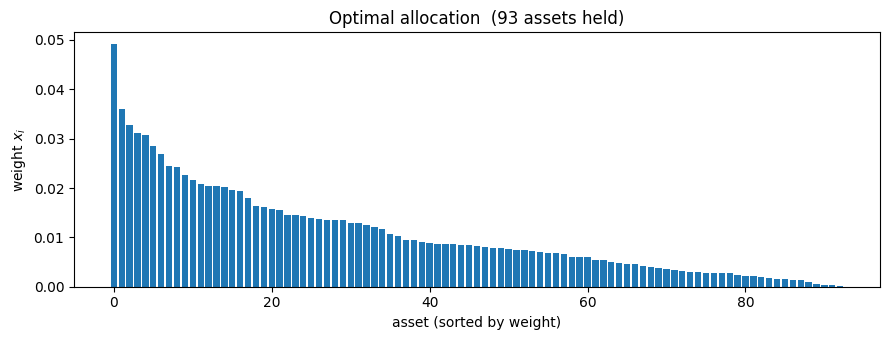

In [4]:
import matplotlib.pyplot as plt

held = np.where(x > 1e-4)[0]
order = held[np.argsort(-x[held])]
plt.figure(figsize=(9, 3.5))
plt.bar(range(len(order)), x[order])
plt.xlabel("asset (sorted by weight)"); plt.ylabel("weight $x_i$")
plt.title(f"Optimal allocation  ({len(order)} assets held)")
plt.tight_layout(); plt.show()

## Check and time against PIQP (CPU)

PIQP solves the identical QP on the CPU. We confirm the objectives match, then time a
single solve. cuPIQP compiles kernels and captures a CUDA graph on its first call, so we
**warm up** before timing.

In [5]:
def time_cupiqp(prob, reps=5):
    s = setup_cupiqp(prob)
    s.solve(); cp.cuda.Device(0).synchronize()          # warm-up (compile + graph capture)
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); s.solve(); cp.cuda.Device(0).synchronize()
        ts.append(time.perf_counter() - t0)
    return s, float(np.median(ts) * 1e3)

def time_piqp(prob, reps=5):
    s = setup_piqp(prob)
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); s.solve()
        ts.append(time.perf_counter() - t0)
    return s, float(np.median(ts) * 1e3)

cu, t_cu = time_cupiqp(prob)
pq, t_pq = time_piqp(prob)

print("objective  cuPIQP = %.6f" % objective(prob, cu.result.x.get()[0]))
print("objective  PIQP   = %.6f" % objective(prob, np.asarray(pq.result.x)))
print("max |x_cuPIQP - x_PIQP| = %.2e" % np.max(np.abs(cu.result.x.get()[0] - np.asarray(pq.result.x))))
print()
print(f"single solve (n = {n}):  cuPIQP (GPU) = {t_cu:6.2f} ms     PIQP (CPU) = {t_pq:6.2f} ms")
print("At this size the CPU solver is competitive - GPU launch/transfer overhead dominates "
      "a small solve. Now grow the problem.")

objective  cuPIQP = -0.843475
objective  PIQP   = -0.843475
max |x_cuPIQP - x_PIQP| = 7.16e-13

single solve (n = 1000):  cuPIQP (GPU) =  16.38 ms     PIQP (CPU) =   9.23 ms
At this size the CPU solver is competitive - GPU launch/transfer overhead dominates a small solve. Now grow the problem.


## Scale it up

The GPU pays off on **large** problems. We rebuild the QP at increasing $n$ (with
$k = n/10$) and time one solve on each backend.

> ⚠️ PIQP on the CPU grows steeply — the `n = 10000` case takes several **seconds**, so
> this cell runs for a bit. Trim the `sizes` list to go faster.

In [6]:
sizes = [1000, 2000, 5000, 10000]
rows = []
for n_i in sizes:
    p_i = build_portfolio(n_i, n_i // 10, gamma=1.0)
    _, tc = time_cupiqp(p_i, reps=3)
    _, tp = time_piqp(p_i, reps=1)          # PIQP is slow at large n; one timed solve
    rows.append((n_i, n_i + n_i // 10, tc, tp))
    print(f"n = {n_i:6d}  N = {n_i + n_i//10:6d}   "
          f"cuPIQP = {tc:8.2f} ms   PIQP = {tp:9.2f} ms   speedup = {tp/tc:5.1f}x")

n =   1000  N =   1100   cuPIQP =    16.45 ms   PIQP =      9.62 ms   speedup =   0.6x


n =   2000  N =   2200   cuPIQP =    30.53 ms   PIQP =     57.18 ms   speedup =   1.9x


n =   5000  N =   5500   cuPIQP =    87.48 ms   PIQP =    773.73 ms   speedup =   8.8x


n =  10000  N =  11000   cuPIQP =   275.84 ms   PIQP =  10894.11 ms   speedup =  39.5x


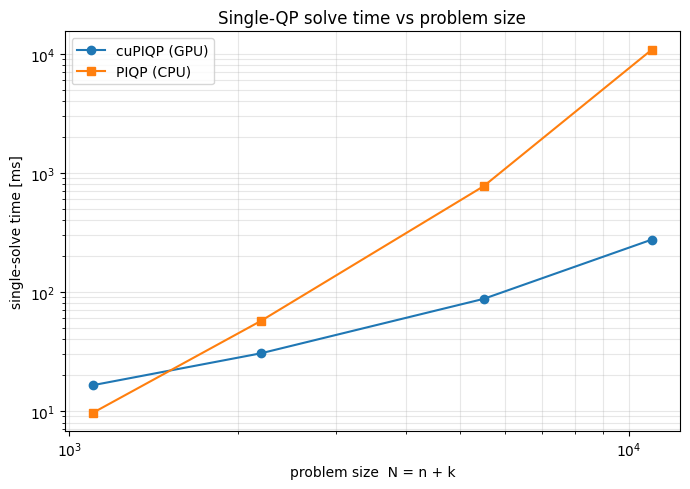

In [7]:
N_vals = [r[1] for r in rows]
cu_ms  = [r[2] for r in rows]
pq_ms  = [r[3] for r in rows]

plt.figure(figsize=(7, 5))
plt.loglog(N_vals, cu_ms, "o-", label="cuPIQP (GPU)")
plt.loglog(N_vals, pq_ms, "s-", label="PIQP (CPU)")
plt.xlabel("problem size  N = n + k"); plt.ylabel("single-solve time [ms]")
plt.title("Single-QP solve time vs problem size")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaways

- cuPIQP solves the sparse QP directly on the GPU and reaches the same optimum as the
  reference CPU solver.
- On a small problem the CPU is competitive (GPU launch overhead). As the single problem
  grows, cuPIQP scales far more gently and pulls orders of magnitude ahead — large
  problems are where the GPU solver shines.